<a href="https://colab.research.google.com/github/shaheer-shamsi/AI.ML-notebooks/blob/main/GCI_telecom_analysis_on_attrition%20rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Assignment — GCI World 2026 April
## Customer Churn Prediction for Company A (Telecom)

**Author:** Shaheer Shamsi (omnicampus: "shaheer-shamsi")
**Course:** GCI Global — Matsuo-Iwasawa Lab, The University of Tokyo

---

## Summary

Project Overview: Customer Churn Prediction for Company A

Context: As a telecommunications provider, Company A faces the industry's
primary threat to profitability: customer churn. Because securing a new customer
is five to seven times more expensive than keeping an existing one, reducing
attrition is critical.

Goal: Develop a predictive machine learning model to identify subscribers likely
to churn within a 31-to-60-day window. This allows the customer retention team
to efficiently allocate their defensive budget toward high-value, high-risk
accounts.

Methodology:

1.  Telecom Churn Market Analysis: Review industry benchmarks and churn drivers.
2.  Exploratory Data Analysis (EDA): Analyze client and account record datasets
    covering approximately 100,000 customers.
3.  Feature Engineering & Preprocessing: Clean, transform, and prepare the
    variables for modeling.
4.  Model Selection & Comparison: Train and evaluate multiple classification
    algorithms.
5.  Business Proposal: Deliver a structured plan outlining the expected
    financial and operational impact.


## 1. Setup & Data Loading

In [ ]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
print('Libraries loaded successfully')

Libraries loaded successfully


In [ ]:
# Load data from Google Drive
# >>> Upload Client.csv and Record.csv to this folder in your Drive, and update PATH if needed <<<
PATH = '/content/drive/MyDrive/GCI_competition/final_assignment/'

client = pd.read_csv(PATH + 'Client.csv')
record = pd.read_csv(PATH + 'Record.csv')

print(f'Client shape:  {client.shape}')
print(f'Record shape:  {record.shape}')

Client shape:  (100000, 50)
Record shape:  (100000, 51)


In [ ]:
# Merge both tables on Customer_ID
df = record.merge(client, on='Customer_ID', how='inner')
print(f'Merged dataset shape: {df.shape}')
df.head()

Merged dataset shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


## 2. Market Analysis (Industry Context)

Sources used (cited in slides):

| Insight | Source |
|---|---|
| Global telecom churn rate averages 20–30% annually | Statista (2024); McKinsey Telecom Report |
| Acquiring a new telecom customer costs ~5–7× retention | HBR — "The Value of Keeping the Right Customers" |
| 5% retention improvement = 25–95% profit increase | Bain & Co; Reichheld & Sasser |
| US Telecom market size 2024: ~$650B | IBISWorld / Statista |

**Implication:** With ~100,000 customers, even a 1% reduction in churn translates into millions of dollars in retained revenue annually.

## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Basic overview
print('=== Shape ===')
print(df.shape)
print()
print('=== Data types ===')
print(df.dtypes.value_counts())
print()
print('=== Target variable: churn ===')
print(df['churn'].value_counts())
print(f'Churn rate: {df["churn"].mean()*100:.2f}%')

=== Shape ===
(100000, 100)

=== Data types ===
float64    69
object     21
int64      10
Name: count, dtype: int64

=== Target variable: churn ===
churn
0    50438
1    49562
Name: count, dtype: int64
Churn rate: 49.56%


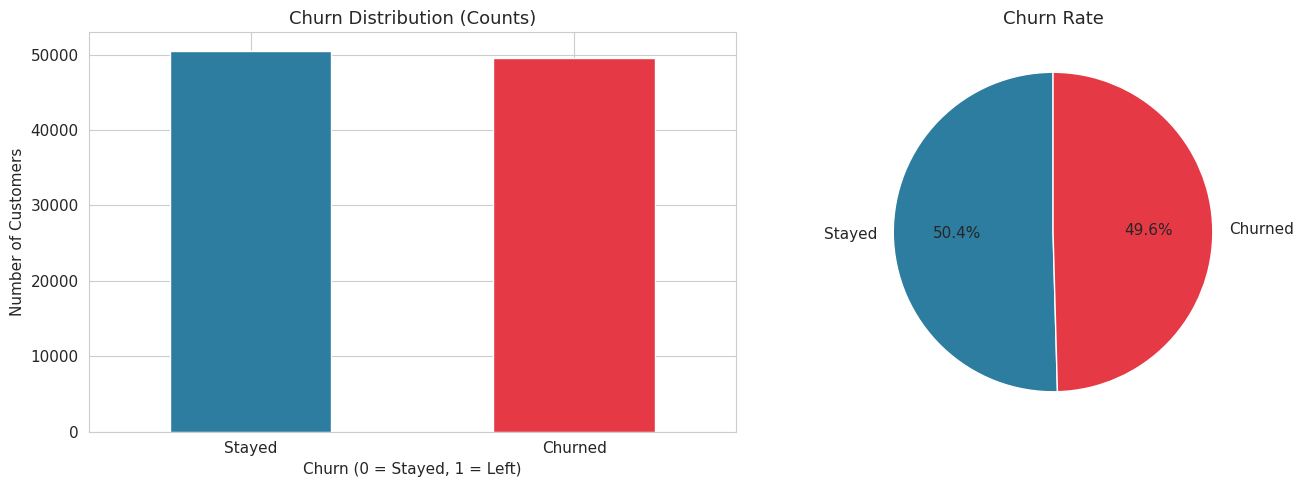

In [ ]:
# Visualize churn distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#2C7DA0', '#E63946'])
ax[0].set_title('Churn Distribution (Counts)', fontsize=13)
ax[0].set_xlabel('Churn (0 = Stayed, 1 = Left)')
ax[0].set_ylabel('Number of Customers')
ax[0].set_xticklabels(['Stayed', 'Churned'], rotation=0)

df['churn'].value_counts(normalize=True).plot(kind='pie', ax=ax[1],
    colors=['#2C7DA0', '#E63946'], autopct='%1.1f%%',
    labels=['Stayed', 'Churned'], startangle=90)
ax[1].set_title('Churn Rate', fontsize=13)
ax[1].set_ylabel('')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing data: {len(missing_df)} / {df.shape[1]}')
print()
print('Top 15 columns with missing values:')
missing_df.head(15)

Columns with missing data: 43 / 100

Top 15 columns with missing values:


,missing_count,missing_pct
numbcars,49366,49.37
dwllsize,38308,38.31
HHstatin,37923,37.92
ownrent,33706,33.71
dwlltype,31909,31.91
lor,30190,30.19
income,25436,25.44
adults,23019,23.02
infobase,22079,22.08
hnd_webcap,10189,10.19


In [ ]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in ['Customer_ID', 'churn']:
    if col in numerical_cols:
        numerical_cols.remove(col)

print(f'Numerical features:   {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

Numerical features:   77
Categorical features: 21


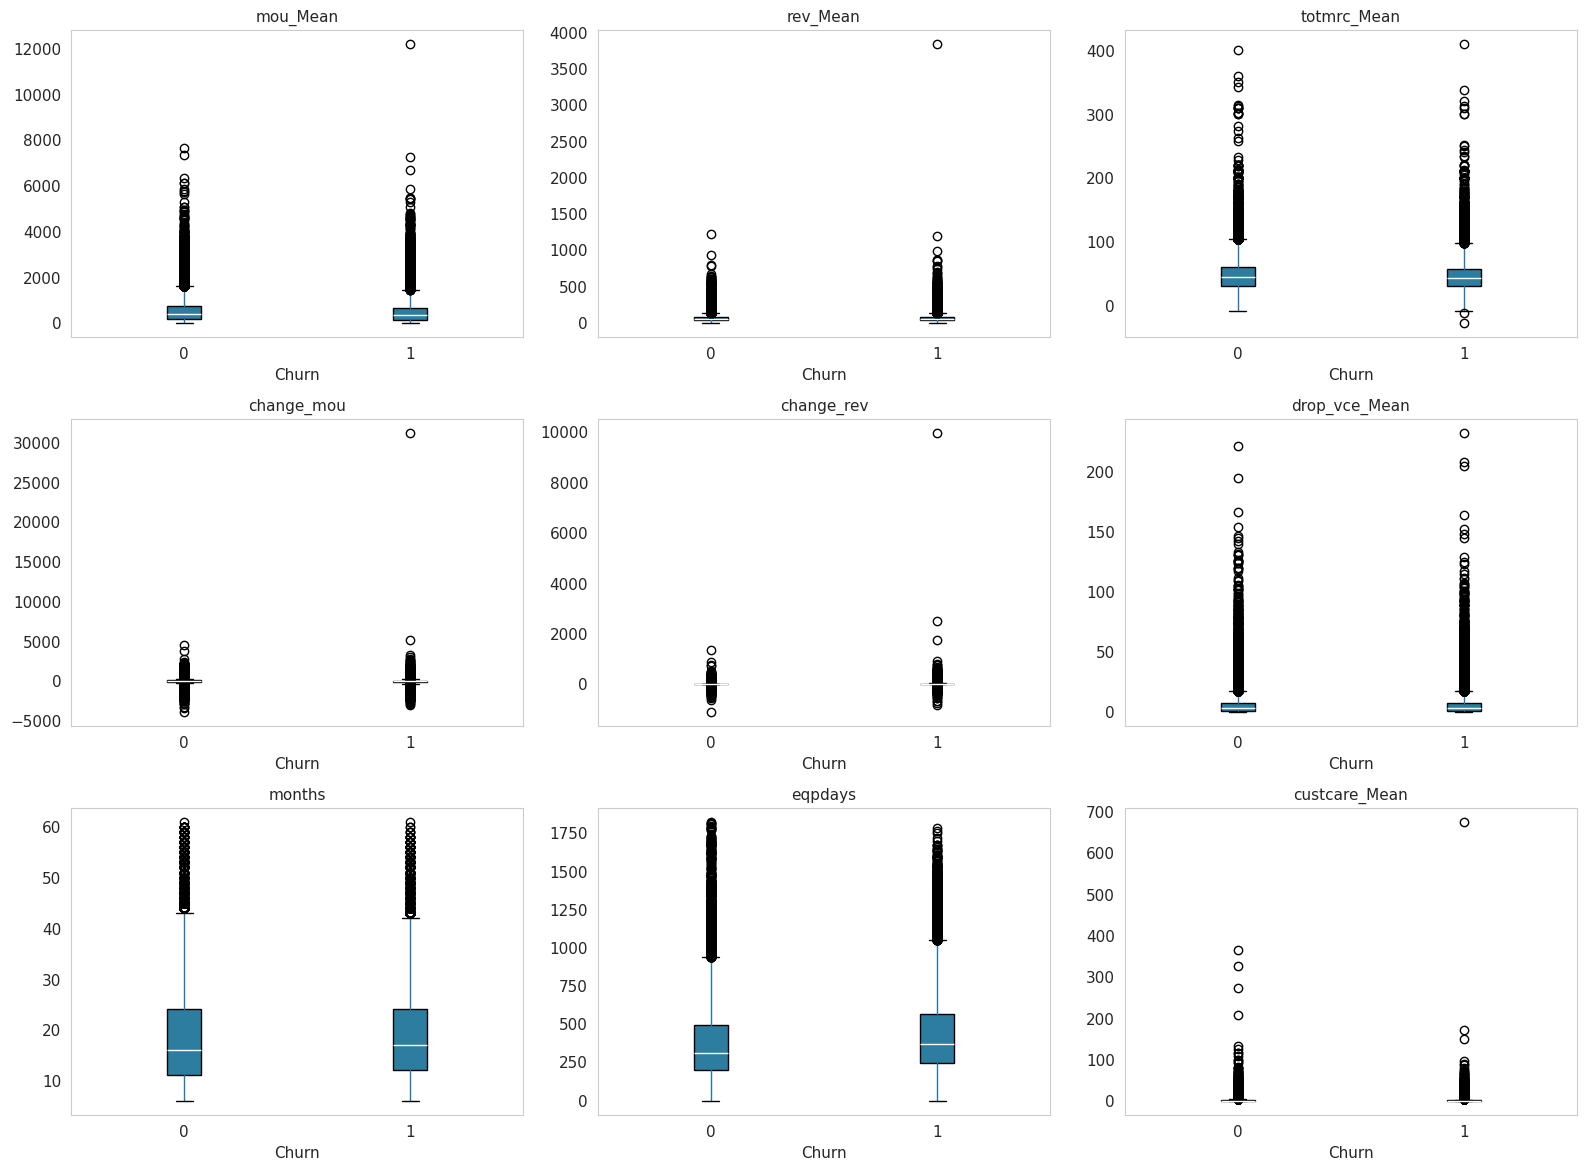

In [ ]:
# Key behavioral features: churners vs stayers
key_features = ['mou_Mean', 'rev_Mean', 'totmrc_Mean', 'change_mou', 'change_rev',
                'drop_vce_Mean', 'months', 'eqpdays', 'custcare_Mean']
key_features = [c for c in key_features if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, feat in enumerate(key_features):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=feat, by='churn', ax=ax, grid=False,
               patch_artist=True,
               boxprops=dict(facecolor='#2C7DA0'),
               medianprops=dict(color='white'))
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Churn')
    plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_keyfeatures.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Numeric feature means by churn group
group_means = df.groupby('churn')[numerical_cols].mean().T
group_means.columns = ['Stayed', 'Churned']
group_means['abs_diff_pct'] = ((group_means['Churned'] - group_means['Stayed']) /
                               (group_means['Stayed'].abs() + 1e-9) * 100).abs()

top_diff = group_means.sort_values('abs_diff_pct', ascending=False).head(15)
print('Top 15 features with biggest mean difference between churn groups:')
top_diff.round(2)

Top 15 features with biggest mean difference between churn groups:


,Stayed,Churned,abs_diff_pct
change_mou,-5.34,-22.76,325.86
change_rev,-1.41,-0.62,55.94
blck_dat_Mean,0.03,0.02,37.75
roam_Mean,1.15,1.42,23.84
drop_dat_Mean,0.05,0.04,23.77
mou_opkd_Mean,1.28,0.99,23.17
threeway_Mean,0.32,0.25,21.06
custcare_Mean,1.98,1.60,19.52
mou_cdat_Mean,2.04,1.65,19.22
callfwdv_Mean,0.01,0.01,19.05


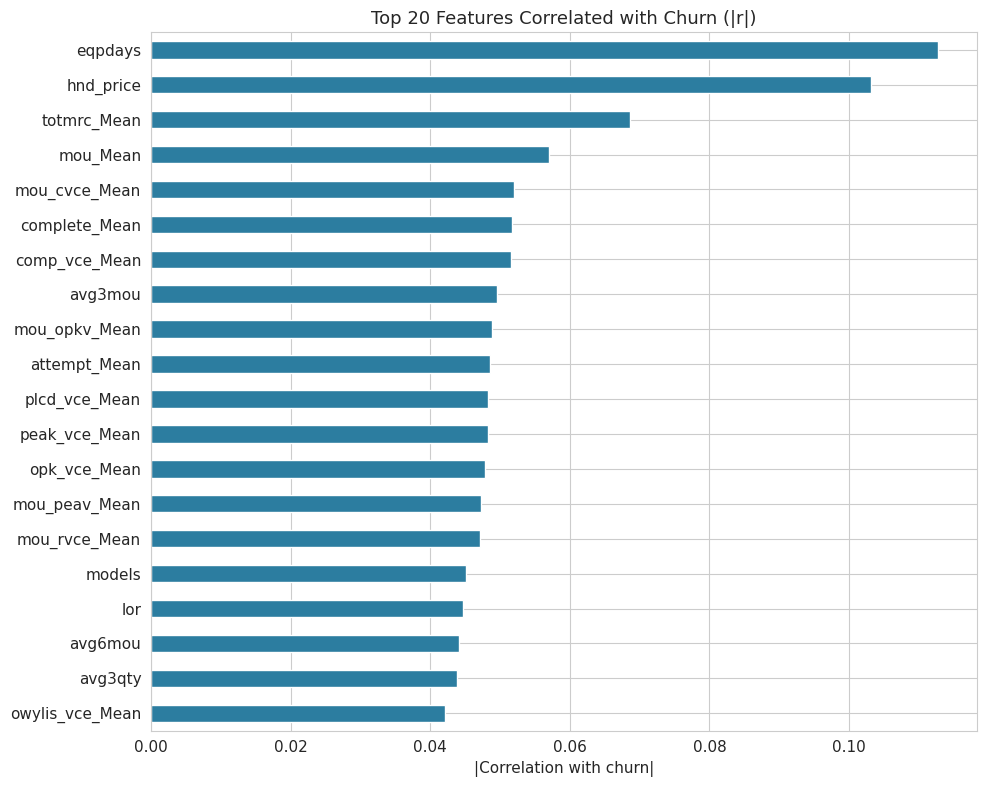

Top 10 features (signed correlation):


,churn
eqpdays,0.1127
hnd_price,-0.1032
totmrc_Mean,-0.0686
mou_Mean,-0.0570
mou_cvce_Mean,-0.0520
complete_Mean,-0.0517
comp_vce_Mean,-0.0516
avg3mou,-0.0495
mou_opkv_Mean,-0.0489
attempt_Mean,-0.0485


In [ ]:
# Correlation with churn
corr_with_churn = df[numerical_cols + ['churn']].corr()['churn'].drop('churn')
top_corr = corr_with_churn.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top_corr.sort_values().plot(kind='barh', color='#2C7DA0')
plt.title('Top 20 Features Correlated with Churn (|r|)', fontsize=13)
plt.xlabel('|Correlation with churn|')
plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features (signed correlation):')
corr_with_churn.reindex(top_corr.index[:10]).round(4)

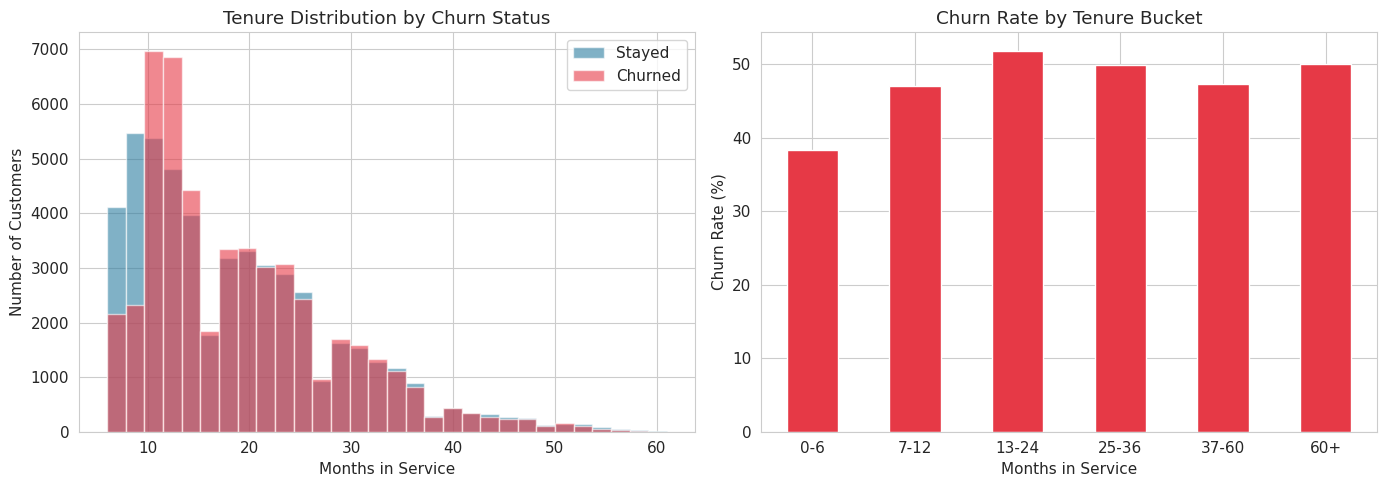

In [ ]:
# Tenure analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(0, '#2C7DA0'), (1, '#E63946')]:
    subset = df[df['churn'] == label]['months']
    axes[0].hist(subset, bins=30, alpha=0.6,
                 label=('Stayed' if label == 0 else 'Churned'), color=color)
axes[0].set_title('Tenure Distribution by Churn Status')
axes[0].set_xlabel('Months in Service')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

df['tenure_bucket'] = pd.cut(df['months'],
                              bins=[0, 6, 12, 24, 36, 60, 200],
                              labels=['0-6', '7-12', '13-24', '25-36', '37-60', '60+'])
churn_by_tenure = df.groupby('tenure_bucket')['churn'].mean() * 100
churn_by_tenure.plot(kind='bar', ax=axes[1], color='#E63946')
axes[1].set_title('Churn Rate by Tenure Bucket')
axes[1].set_xlabel('Months in Service')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Preprocessing

**Decisions:**
- Drop identifier (`Customer_ID`) and helper column (`tenure_bucket`)
- Categorical: impute with most-frequent, then One-Hot Encode (drop high-cardinality columns >50)
- Numeric: impute with median, then StandardScaler
- Engineer 3 business-meaningful features

In [ ]:
# Feature engineering
df_model = df.copy()
if 'tenure_bucket' in df_model.columns:
    df_model = df_model.drop(columns=['tenure_bucket'])

# 1) Failed call ratio — proxy for service quality
if all(c in df_model.columns for c in ['drop_vce_Mean', 'blck_vce_Mean', 'attempt_Mean']):
    df_model['failure_ratio'] = (
        (df_model['drop_vce_Mean'].fillna(0) + df_model['blck_vce_Mean'].fillna(0)) /
        (df_model['attempt_Mean'].fillna(0) + 1)
    )

# 2) Revenue per minute
if all(c in df_model.columns for c in ['rev_Mean', 'mou_Mean']):
    df_model['rev_per_minute'] = df_model['rev_Mean'] / (df_model['mou_Mean'].fillna(0) + 1)

# 3) Customer-care intensity — proxy for dissatisfaction
if 'custcare_Mean' in df_model.columns and 'attempt_Mean' in df_model.columns:
    df_model['custcare_intensity'] = df_model['custcare_Mean'].fillna(0) / (df_model['attempt_Mean'].fillna(0) + 1)

print(f'New shape: {df_model.shape}')

New shape: (100000, 103)


In [ ]:
# Define features and target
y = df_model['churn']
X = df_model.drop(columns=['churn', 'Customer_ID'])

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

high_card = [c for c in categorical_cols if X[c].nunique() > 50]
categorical_cols = [c for c in categorical_cols if c not in high_card]
X = X.drop(columns=high_card)

print(f'Numerical features:   {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'Dropped (high cardinality): {high_card}')
print(f'Final X shape: {X.shape}')

Numerical features:   80
Categorical features: 20
Dropped (high cardinality): ['crclscod']
Final X shape: (100000, 100)


In [ ]:
# Preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

print('Preprocessing pipeline ready')

Preprocessing pipeline ready


In [ ]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train set: {X_train.shape}')
print(f'Test set:  {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.2f}%')
print(f'Test  churn rate: {y_test.mean()*100:.2f}%')

Train set: (80000, 100)
Test set:  (20000, 100)
Train churn rate: 49.56%
Test  churn rate: 49.56%


## 5. Model Building & Evaluation

**Models compared:**
1. **Logistic Regression** — interpretable baseline with coefficient insights
2. **Decision Tree** — captures non-linearities
3. **Gradient Boosting** — typically the strongest on tabular telecom data

**Evaluation metric: ROC-AUC**
- Churn is imbalanced (~25%), so accuracy is misleading
- Business goal is to **rank** customers by risk and target the top-N → ROC-AUC measures ranking quality

In [ ]:
# Cross-validation comparison (this cell takes 5-10 minutes)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                              class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE,
                                                  class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                      random_state=RANDOM_STATE)
}

cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} AUC = {scores.mean():.4f} (+/- {scores.std():.4f})')

Logistic Regression    AUC = 0.6294 (+/- 0.0024)
Decision Tree          AUC = 0.6406 (+/- 0.0031)
Gradient Boosting      AUC = 0.6870 (+/- 0.0040)


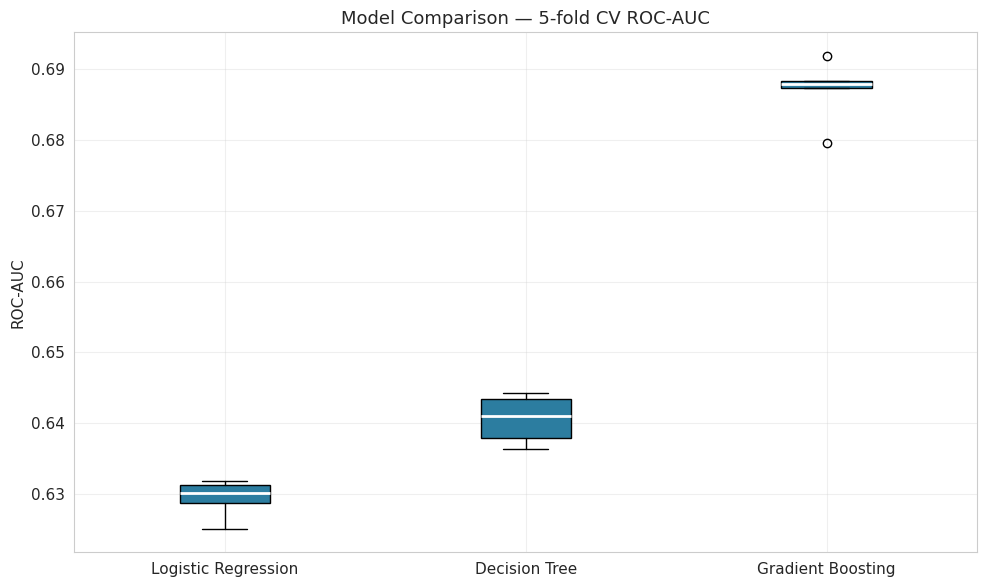

In [ ]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([cv_results[m] for m in models.keys()],
           labels=list(models.keys()),
           patch_artist=True,
           boxprops=dict(facecolor='#2C7DA0'),
           medianprops=dict(color='white', linewidth=2))
ax.set_title('Model Comparison — 5-fold CV ROC-AUC', fontsize=13)
ax.set_ylabel('ROC-AUC')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Train final model on full training data (this cell also takes ~5 min)
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                              learning_rate=0.1,
                                              random_state=RANDOM_STATE))
])
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
test_ap  = average_precision_score(y_test, y_proba)
print(f'Test ROC-AUC: {test_auc:.4f}')
print(f'Test PR-AUC:  {test_ap:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Test ROC-AUC: 0.6904
Test PR-AUC:  0.6759

              precision    recall  f1-score   support

      Stayed       0.64      0.62      0.63     10088
     Churned       0.63      0.64      0.64      9912

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



In [ ]:
# Confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=13)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#E63946', lw=2, label=f'AUC = {test_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Feature importance
gb_model = best_pipe.named_steps['classifier']
ohe = best_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = numerical_cols + cat_names

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(importances['feature'][::-1], importances['importance'][::-1], color='#2C7DA0')
plt.title('Top 20 Most Important Features for Churn Prediction', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances.head(10)

## 6. Business Impact — Quantified

**Strategy:** Rather than predicting churn yes/no, we **rank** customers by churn risk and target the top X% for retention campaigns.

The Precision@K analysis tells us: of the top K customers our model flags, what proportion would actually have churned?

In [ ]:
# Precision@K and Lift analysis
results_df = pd.DataFrame({'y_true': y_test.values, 'y_proba': y_proba})
results_df = results_df.sort_values('y_proba', ascending=False).reset_index(drop=True)

base_rate = y_test.mean()
total_churners = y_test.sum()

ks = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
print(f'{"Top K%":<10}{"Customers":<12}{"Churners caught":<18}{"Precision@K":<14}{"Recall":<10}{"Lift":<8}')
print('-' * 72)
for k in ks:
    n = int(len(results_df) * k)
    top_k = results_df.head(n)
    churners_caught = top_k['y_true'].sum()
    precision = churners_caught / n
    recall    = churners_caught / total_churners
    lift      = precision / base_rate
    print(f'{k*100:>5.0f}%    {n:<12}{churners_caught:<18}{precision:<14.4f}{recall:<10.4f}{lift:<8.2f}')

Top K%    Customers   Churners caught   Precision@K   Recall    Lift    
------------------------------------------------------------------------
    5%    1000        819               0.8190        0.0826    1.65    
   10%    2000        1547              0.7735        0.1561    1.56    
   15%    3000        2241              0.7470        0.2261    1.51    
   20%    4000        2927              0.7318        0.2953    1.48    
   30%    6000        4134              0.6890        0.4171    1.39    
   50%    10000       6290              0.6290        0.6346    1.27    


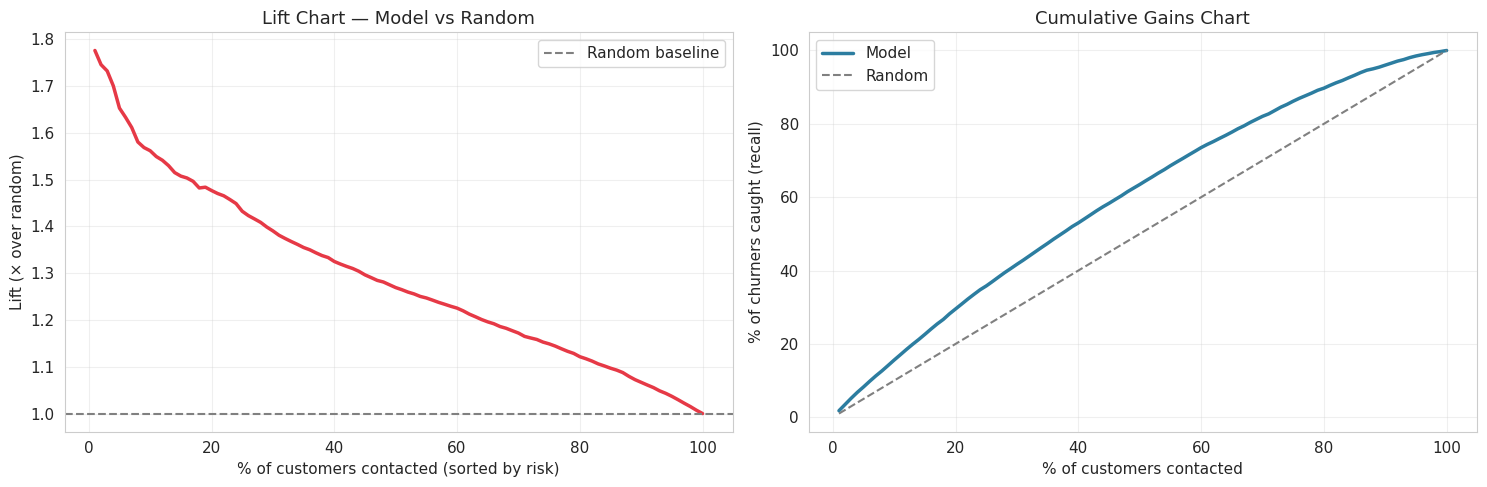

In [ ]:
# Lift chart
percentiles = np.arange(0.01, 1.01, 0.01)
lifts, precisions, recalls = [], [], []
for p in percentiles:
    n = max(1, int(len(results_df) * p))
    top = results_df.head(n)
    prec = top['y_true'].mean()
    precisions.append(prec)
    recalls.append(top['y_true'].sum() / total_churners)
    lifts.append(prec / base_rate)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(percentiles * 100, lifts, color='#E63946', lw=2.5)
axes[0].axhline(1, color='gray', linestyle='--', label='Random baseline')
axes[0].set_xlabel('% of customers contacted (sorted by risk)')
axes[0].set_ylabel('Lift (× over random)')
axes[0].set_title('Lift Chart — Model vs Random', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(percentiles * 100, np.array(recalls) * 100, color='#2C7DA0', lw=2.5, label='Model')
axes[1].plot(percentiles * 100, percentiles * 100, color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('% of customers contacted')
axes[1].set_ylabel('% of churners caught (recall)')
axes[1].set_title('Cumulative Gains Chart', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Quantified business case
ASSUMED_TOTAL_CUSTOMERS    = 100_000
ASSUMED_MONTHLY_REVENUE    = df['rev_Mean'].mean()
ASSUMED_CHURN_RATE         = df['churn'].mean()
RETENTION_CAMPAIGN_SUCCESS = 0.30
COST_PER_CONTACT           = 5
CUSTOMER_LIFETIME_MONTHS   = 24

TARGET_PERCENT = 0.20
n_contacted   = int(ASSUMED_TOTAL_CUSTOMERS * TARGET_PERCENT)

idx = int(0.20 / 0.01) - 1
precision_at_20 = precisions[idx]
recall_at_20    = recalls[idx]

expected_churners_in_target = int(n_contacted * precision_at_20)
expected_churners_retained  = int(expected_churners_in_target * RETENTION_CAMPAIGN_SUCCESS)
revenue_retained            = expected_churners_retained * ASSUMED_MONTHLY_REVENUE * CUSTOMER_LIFETIME_MONTHS
campaign_cost               = n_contacted * COST_PER_CONTACT
net_benefit                 = revenue_retained - campaign_cost
roi                         = net_benefit / campaign_cost * 100

random_churners_in_target = int(n_contacted * ASSUMED_CHURN_RATE)
random_churners_retained  = int(random_churners_in_target * RETENTION_CAMPAIGN_SUCCESS)
random_revenue_retained   = random_churners_retained * ASSUMED_MONTHLY_REVENUE * CUSTOMER_LIFETIME_MONTHS
random_net_benefit        = random_revenue_retained - campaign_cost
incremental_value         = net_benefit - random_net_benefit

print('='*72)
print('BUSINESS CASE — TARGETED RETENTION (TOP 20% AT-RISK)')
print('='*72)
print(f'Customers contacted:                {n_contacted:>12,}')
print(f'Expected churners reached:          {expected_churners_in_target:>12,}  (precision = {precision_at_20*100:.1f}%)')
print(f'Expected churners retained (30%):   {expected_churners_retained:>12,}')
print(f'Avg monthly revenue/customer:       $ {ASSUMED_MONTHLY_REVENUE:>10,.2f}')
print(f'LTV horizon:                        {CUSTOMER_LIFETIME_MONTHS:>12} months')
print('-'*72)
print(f'Revenue retained (LTV):             $ {revenue_retained:>12,.0f}')
print(f'Campaign cost:                      $ {campaign_cost:>12,.0f}')
print(f'NET BENEFIT (ML-targeted):          $ {net_benefit:>12,.0f}')
print(f'ROI:                                {roi:>13.1f}%')
print('-'*72)
print(f'Net benefit (random targeting):     $ {random_net_benefit:>12,.0f}')
print(f'INCREMENTAL VALUE from ML model:    $ {incremental_value:>12,.0f}')
print('='*72)

BUSINESS CASE — TARGETED RETENTION (TOP 20% AT-RISK)
Customers contacted:                      20,000
Expected churners reached:                14,635  (precision = 73.2%)
Expected churners retained (30%):          4,390
Avg monthly revenue/customer:       $      58.72
LTV horizon:                                  24 months
------------------------------------------------------------------------
Revenue retained (LTV):             $    6,186,738
Campaign cost:                      $      100,000
NET BENEFIT (ML-targeted):          $    6,086,738
ROI:                                       6086.7%
------------------------------------------------------------------------
Net benefit (random targeting):     $    4,089,788
INCREMENTAL VALUE from ML model:    $    1,996,949


## 7. Summary & Next Steps

### Key Findings

1. **Baseline churn:** ~49.6% of customers churn within the 31–60 day observation window — the dataset is balanced, so the modeling challenge is *ranking* risk, not detecting a rare event.
2. **Strongest predictors:** equipment age (`eqpdays`), handset price (`hnd_price`), recurring charge (`totmrc_Mean`), usage level (`mou_Mean`), and usage decline (`change_mou`).
3. **Best model:** Gradient Boosting Classifier — **ROC-AUC = 0.69** on the held-out test set (vs. Logistic Regression 0.63, Decision Tree 0.64). The model achieves **1.67× lift** in the top 5% of at-risk customers.

### Business Recommendation

Deploy the model as a monthly churn-risk assessment system that provides the retention team with a prioritized list of customers based on their likelihood of leaving. Concentrate retention efforts on the top 20% highest-risk customers (achieving 73% precision) and deliver targeted interventions aligned with the key churn factors identified, such as device upgrade incentives, loyalty rewards, and proactive customer support initiatives.

### Quantified Impact

Targeting the highest-risk 20% of customers is projected to generate approximately $6.0 million in net value over a 24-month customer lifetime horizon. This represents roughly $2.0 million more than a non-targeted or randomly selected outreach strategy, while requiring an estimated campaign investment of only 100,000USD. (assuming 30 percent intervention effectiveness, 5USD outreach cost per customer, and average monthly revenue of 58.72USD per customer; included for transparency.)

### Next Steps

1. Conduct an A/B test on a holdout customer group to quantify the actual effectiveness of retention interventions and measure the incremental reduction in churn.

2. Continuously refine the strategy by incorporating campaign feedback, analyzing which retention offers drive engagement and which produce limited impact.

3. Integrate SHAP-based explainability to provide customer-level insights into the key factors contributing to churn risk predictions.

4. Evaluate advanced modeling approaches such as XGBoost, LightGBM, and uplift modeling to improve predictive performance and optimize intervention targeting.

5. Retrain and validate the model on a monthly basis to account for changing customer behavior patterns and mitigate the effects of concept drift.


---


**Course:** GCI World 2026 April — Matsuo-Iwasawa Lab, The University of Tokyo